# Regridding HI / foreground / noise maps to a Cartesian grid with `gridimp`

Takes the HEALPix HI, synchrotron+free-free, and noise maps used in `SMICA_HI.ipynb` and regrids them onto a shared Cartesian `(nx,ny,nz)` grid using [gridimp](https://github.com/stevecunnington/gridimp), so that a P(k) estimator can be run on them


```
conda activate gridimp
```

TODO: make flow better with loading recovery stuff later in the notebook less edits etc etc...

In [1]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy import units as u
from astropy_healpix import HEALPix

# NOTE: gridimp's own `model.py` calls cosmo.H(0) at import time, which needs
# cosmo.SetCosmology() to have already been run. So only `cosmo` is imported here;
# `grid`, `line`, `power` are imported further down, right after SetCosmology() runs.
from gridimp import cosmo

## Survey and frequency setup

Matches the values used in `SMICA_HI.ipynb`: `nside=256`, 10 MHz channels from 544-1088 MHz, and the RA/Dec patch mask.

In [2]:
nside = 256
# freqs = np.arange(544, 1088, step=10)  # MHz, channel edges as defined in SMICA_HI.ipynb
freqs = np.arange(1042,1183, step=1)  
nu = freqs[:-1].astype(float)          # channel values actually populated in the maps
                                        # (float: gridimp's comoving_dims does in-place float arithmetic on nu_p)
nfreqs = len(nu)

# Shrunk from the original 120x65 deg patch (-60,60 / -75,-10) to a 20x20 deg patch around the
# same field center (RA=0, Dec=-42.5), matching gridimp's own toy.py example scale -- testing
# whether the wide-angle flat-sky projection was causing the regridding artifacts seen above
# (partial coverage wedge in W_fft + spatial-vs-spectral mixing noise in fg_cube).
ramin, ramax = -10.0, 10.0    # deg
decmin, decmax = -52.5, -32.5 # deg

numin, numax = nu[0], nu[-1]
print(f"nfreqs={nfreqs}, {numin}-{numax} MHz")

nfreqs=140, 1042.0-1181.0 MHz


In [3]:
(52.5+32.5)/2

42.5

## Set cosmology


In [4]:
from gridimp import line
from astropy.cosmology import FlatLambdaCDM

# Cosmology used to generate the HI maps (flat LCDM, matches CAMB: H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2):
h = 0.7
Oc = 0.25
Ob = 0.05

# Set gridimp's cosmology globals directly (mirrors what cosmo.SetCosmology() does internally,
# but with the sim's actual cosmology instead of a Planck15/Planck18 preset):
cosmo.cosmo_ = FlatLambdaCDM(H0=100 * h, Om0=Oc + Ob, Ob0=Ob)
cosmo.H_0 = cosmo.cosmo_.H(0).value
cosmo.h = cosmo.H_0 / 100
cosmo.Om0 = Oc + Ob
cosmo.Ob0 = Ob
# n_s/A_s are only used by cosmo.GetModelPk() (not called in this notebook) - if you use that later,
# set these to match the primordial parameters from your sim too:
# cosmo.n_s = 0.965
# cosmo.A_s = 2.14e-9

zmin, zmax = line.nu21cm_to_z(numax), line.nu21cm_to_z(numin)
zeff = np.mean([zmin, zmax])
print(f"Frequency range {numin}-{numax} MHz -> redshift range {zmin:.3f} < z < {zmax:.3f} (zeff={zeff:.3f})")
print(f"Cosmology: H0={cosmo.H_0:.2f}, Om0={cosmo.Om0:.3f}, Ob0={cosmo.Ob0:.3f}")

# Safe to import now that cosmo_ (and friends) have been set:
from gridimp import grid, power

Frequency range 1042.0-1181.0 MHz -> redshift range 0.203 < z < 0.363 (zeff=0.283)
Cosmology: H0=70.00, Om0=0.300, Ob0=0.050


## Load simulated maps

Loads the celestial-frame (rotated) HI, foreground and noise maps that `SMICA.ipynb` already caches, so the
RA/Dec patch mask below (defined in celestial coordinates) selects the same patch of sky as the SMICA fit --
the raw simulated maps are in galactic coordinates and must not be masked with this RA/Dec box directly.

In [5]:
input_path = "/datadec/cppm/shoaib/SMICA_Paper/data/UHF"

# Maps are simulated in galactic coordinates; the RA/Dec patch mask below is defined in
# celestial coordinates (matches SMICA.ipynb). Load the celestial-rotated caches instead
# of the raw galactic maps -- loading the raw maps here would silently select the wrong
# patch of sky (same numeric RA/Dec box, but read off galactic lon/lat instead).
hi    = np.load(f"{input_path}/rotated_hi_1042_1183.npy")[:-1]     # mK, celestial
fgds  = np.load(f"{input_path}/rotated_fgds_1042_1183.npy")[:-1]   # mK, celestial
noise = np.load(f"{input_path}/rotated_noise_1042_1183.npy")[:-1]  # celestial (unit scaling not addressed here, see SMICA.ipynb)

# hi_recovered    = np.load(f"{input_path}/hi_smica_recovered_1042_1183.npy")     # mK, celestial
# fgds_recovered  = np.load(f"{input_path}/fg_smica_recovered_1042_1183.npy")   # mK, celestial
hi_recovered    = np.load(f"{input_path}/hi_smica_8bins.npy")     # mK, celestial
fgds_recovered  = np.load(f"{input_path}/fg_smica_8bins.npy")   # mK, celestial

dirty = hi + fgds + noise  # HI + foregrounds + noise: the "observed" cube to be cleaned downstream

assert hi.shape == (nfreqs, hp.nside2npix(nside)), hi.shape
print("map shape (nfreqs, npix):", hi.shape)

map shape (nfreqs, npix): (140, 786432)


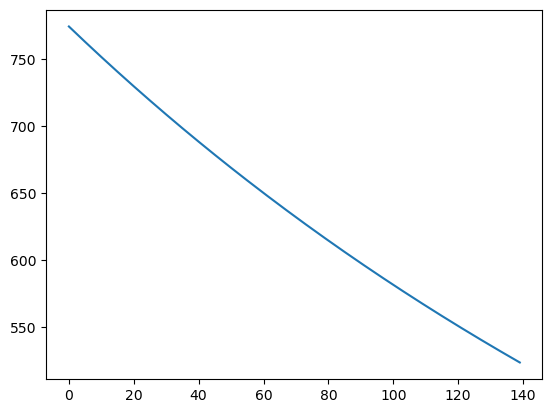

In [6]:
plt.plot(fgds[:,32]) #thisis what my fg gridden cube should look like, 
#it matches the amp for GPR as wells so whats happening??

### Sanity-check map units

All four fields should be in mK 

In [7]:
print(f"HI    std = {np.std(hi):.4g} mK   (expect ~1e-2-1 mK: the faint cosmological signal)")
print(f' HI recovered std = {np.std(hi_recovered):.4g} mK   (should be close to the original HI std)')
print(f"FG    std = {np.std(fgds):.4g} mK   (expect several orders of magnitude brighter than HI)")
print(f' FG recovered std = {np.std(fgds_recovered):.4g} mK   (should be close to the original FG std)')
print(f"Noise std = {np.std(noise):.4g} mK")
print(f"Dirty std = {np.std(dirty):.4g} mK   (should be dominated by FG)")

HI    std = 0.0917 mK   (expect ~1e-2-1 mK: the faint cosmological signal)
 HI recovered std = 0.03411 mK   (should be close to the original HI std)
FG    std = 1890 mK   (expect several orders of magnitude brighter than HI)
 FG recovered std = 228.6 mK   (should be close to the original FG std)
Noise std = 2.004e-08 mK
Dirty std = 1890 mK   (should be dominated by FG)


## Identify sky-patch pixels and comoving box dimensions

Uses `gridimp`'s own `grid.init_healpix` for the RA/Dec patch mask (same logic as `SMICA_HI.ipynb`'s
`create_sky_patch_mask`, but keeping the pixel `(RA, Dec)` coordinates rather than a 0/1 map, since
`gridimp` needs the actual coordinates of the on-patch pixels).

In [8]:
hp0 = HEALPix(nside)

# grid.init_healpix does the same RA/Dec masking as before (wraps RA to [-180,180], cuts on
# ramin/ramax/decmin/decmax) and returns the masked pixel (ra,dec). 
ra_patch, dec_patch, _, _ = grid.init_healpix(nside, ramin, ramax, decmin, decmax, numin, numax, nnu=nfreqs, n0=2)
#n0 is just a dummy doesnt use it

# ipix_patch for the pixel-counting 
ipix_patch = hp0.lonlat_to_healpix(ra_patch, dec_patch)

print(f"Patch contains {len(ipix_patch)} of {hp0.npix} HEALPix pixels")

Patch contains 5567 of 786432 HEALPix pixels


In [9]:
# Survey area and sky fraction.
# Analytic: solid angle of a RA/Dec rectangle needs the cos(Dec) weighting
# (lines of constant RA converge toward the poles), so it's not just dRA*dDec.
dra = np.radians(ramax - ramin)
dsin = np.sin(np.radians(decmax)) - np.sin(np.radians(decmin))
area_sr = dra * dsin
fullsky_deg2 = 4 * np.pi * (180 / np.pi) ** 2
area_deg2 = area_sr * (180 / np.pi) ** 2
fsky_analytic = area_deg2 / fullsky_deg2

# Cross-check via pixel counting (should closely match the analytic value):
fsky_pixel = len(ipix_patch) / hp0.npix
area_deg2_pixel = fsky_pixel * fullsky_deg2

print(f"Survey area (analytic):       {area_deg2:.1f} deg^2   (fsky = {fsky_analytic:.4f})")
print(f"Survey area (pixel counting): {area_deg2_pixel:.1f} deg^2   (fsky = {fsky_pixel:.4f})")

Survey area (analytic):       293.4 deg^2   (fsky = 0.0071)
Survey area (pixel counting): 292.0 deg^2   (fsky = 0.0071)


## Flat-sky (parallel-planes) projection, replacing `grid.SkyCoordtoCartesian`/`grid.comoving_dims`

`gridimp`'s own `SkyCoordtoCartesian` scales **all three** Cartesian axes (transverse x,y *and*
line-of-sight z) by each particle's own frequency-dependent comoving distance `d(ν)`. That's a
literal 3D light-cone projection, but it means a fixed transverse box position doesn't track a
fixed sky direction -- it drifts across frequency, and near the ends of the band this drift
becomes angle-dependent enough to carve a circular cutoff out of the (rectangular) survey mask
(confirmed above: the coverage mask went from a clean square in the interior of the z-range to a
circle inscribed in it near the edges).

Use the flat-sky/parallel-planes approximation instead: use a single **fixed**
reference comoving distance `d_ref` (at the band's effective redshift) for the transverse x,y
axes, and only let the line-of-sight z axis depend on frequency. That keeps every sightline
(fixed x,y, varying z) pointed at the same sky direction for every channel.

Separately, snapping the z-grid's cell width exactly to the true channel-to-channel comoving
spacing (rather than letting the z0/z0+lz buffer inflate it slightly) turned out to matter too:
`Hz=lz/nz` from `grid.comoving_dims` came out ~6% wider than the true per-channel spacing, which
created a resampling beat/aliasing pattern (a channel's position within its cell drifts and wraps
roughly every ~10-15 channels) -- this, not sparse Np or patch size, was the source of the
sawtooth ripple in every `fg_cube[x,y,:]` sightline plot above.

In [10]:
d_ref = cosmo.d_com(zeff)  # fixed reference comoving distance for the transverse axes (Mpc/h)
print(f"Flat-sky reference distance d_ref = {d_ref:.1f} Mpc/h at zeff={zeff:.3f}")

def flatsky_cartesian(ra_deg, dec_deg, d_los, ra_mean_deg, dec_mean_deg, d_ref):
    """Parallel-planes projection: transverse x,y use the FIXED d_ref (so a fixed transverse
    position always corresponds to the same angular offset from the field center, at every
    frequency); only the line-of-sight z uses the particle's own (frequency-dependent) d_los."""
    ra = np.copy(ra_deg); ra = np.where(ra > 180, ra - 360, ra)
    ram = np.copy(ra_mean_deg); ram = np.where(ram > 180, ram - 360, ram)
    dec0 = np.mean(dec_mean_deg)  # patch CENTER declination -- a single fixed number for the whole patch
    ra = ra - np.mean(ram)
    dec = dec_deg - dec0
    ra_rad, dec_rad = np.radians(ra), np.radians(dec)
    # RA lines converge toward the poles, so a degree of RA is worth less physical distance the
    # further |dec0| is from the equator. That correction is a FIXED cos(dec0) for the whole patch
    # (this is a property of the RA/Dec grid on the sphere, unrelated to d_ref being fixed or not) --
    # using cos(dec-dec0) instead (the offset from center, which stays ~1 for a patch this narrow)
    # was under-correcting lx by ~35% at this patch's dec0=-42.5.
    x = d_ref * np.cos(np.radians(dec0)) * ra_rad
    y = d_ref * dec_rad
    return x, y, d_los

def flatsky_dims(ra_patch, dec_patch, nu, d_ref, ndim):
    """Replacement for grid.comoving_dims, consistent with flatsky_cartesian above. The z-grid
    cell width is snapped exactly to the true channel-to-channel comoving spacing (rather than
    letting a buffer move lz/nz away from it) to avoid the resampling beat pattern found above."""
    ra_deg = ra_patch.to(u.deg).value
    dec_deg = dec_patch.to(u.deg).value
    x_all, y_all, _ = flatsky_cartesian(ra_deg, dec_deg, np.zeros_like(ra_deg), ra_deg, dec_deg, d_ref)
    ang_buffer = 1 * hp0.pixel_resolution.to(u.rad).value  # ~1 native HEALPix pixel margin, enough to
                                                            # absorb the Monte Carlo satellite jitter in x,y
    x_lo, x_hi = x_all.min() - d_ref * ang_buffer, x_all.max() + d_ref * ang_buffer
    y_lo, y_hi = y_all.min() - d_ref * ang_buffer, y_all.max() + d_ref * ang_buffer

    # Negated: d_com increases as frequency DECREASES (higher z), so without the flip, cube
    # z-index would increase with decreasing frequency -- backwards relative to `nu`'s own
    # order and to the GPR reference cubes. Negating makes increasing z-index track increasing
    # frequency instead (an overall sign flip on one Cartesian axis doesn't change P(k), which
    # only depends on |k|).
    z_chan = -cosmo.d_com(line.nu21cm_to_z(nu))
    nx, ny, nz = ndim
    Hz = (z_chan.max() - z_chan.min()) / (nz - 1)  # true per-channel spacing, not buffer affected
    z_lo = z_chan.min() - Hz / 2
    lz = nz * Hz
    return [x_hi - x_lo, y_hi - y_lo, lz, nx, ny, nz, x_lo, y_lo, z_lo]

Flat-sky reference distance d_ref = 792.0 Mpc/h at zeff=0.283


In [11]:
# n_fft = 64  # output grid resolution in the two transverse (nx,ny) directions
#             # nz is kept at the native frequency resolution (nfreqs) so GPR can later fit along real channels

# dims_fft = flatsky_dims(ra_patch, dec_patch, nu, d_ref, ndim=(n_fft, n_fft, nfreqs))
# lx, ly, lz, nx, ny, nz, x0, y0, z0 = dims_fft
# print(f"Box size (Mpc/h): {lx:.1f} x {ly:.1f} x {lz:.1f}")
# print(f"Grid cells: {nx} x {ny} x {nz}")
# print(f"~{lx/nx:.1f} x {ly/ny:.1f} pixel size")

In [12]:
# nx,ny chosen separately (rather than one square n_fft) because the patch itself isn't square in
# Mpc/h (lx != ly at this dec0) -- matching GPR's cell size (500/128=3.906 Mpc/h) on each axis
# independently keeps voxels ~isotropic and puts our k_perp Nyquist in line with the GPR reference cube.
# nz is kept at the native frequency resolution (nfreqs) so GPR can later fit along real channels.
gpr_cell_size = 500.0 / 128  # Mpc/h, from Understanding_GPR's lx_g/nx_g
nx = round((d_ref * np.cos(np.radians((decmin + decmax) / 2)) * np.radians(ramax - ramin)) / gpr_cell_size)
ny = round((d_ref * np.radians(decmax - decmin)) / gpr_cell_size)

dims_fft = flatsky_dims(ra_patch, dec_patch, nu, d_ref, ndim=(nx, ny, nfreqs))
lx, ly, lz, nx, ny, nz, x0, y0, z0 = dims_fft
print(f"Box size (Mpc/h): {lx:.1f} x {ly:.1f} x {lz:.1f}")
print(f"Grid cells: {nx} x {ny} x {nz}")
print(f"~{lx/nx:.1f} x {ly/ny:.1f} pixel size")

Box size (Mpc/h): 211.3 x 280.0 x 419.5
Grid cells: 52 x 71 x 140
~4.1 x 3.9 pixel size


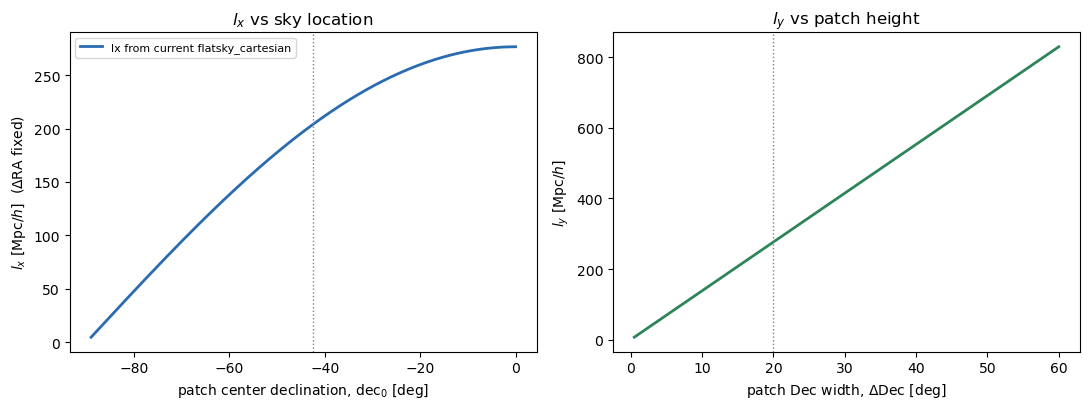

In [13]:
def lx_via_code(dra_deg, dec0_deg):
    ra_test = np.array([-dra_deg / 2, dra_deg / 2])
    dec_test = np.array([dec0_deg, dec0_deg])
    x, _, _ = flatsky_cartesian(ra_test, dec_test, np.zeros(2), ra_test, dec_test, d_ref)
    return x.max() - x.min()

def ly_via_code(ddec_deg, dec0_deg):
    ra_test = np.array([0.0, 0.0])
    dec_test = np.array([dec0_deg - ddec_deg / 2, dec0_deg + ddec_deg / 2])
    _, y, _ = flatsky_cartesian(ra_test, dec_test, np.zeros(2), ra_test, dec_test, d_ref)
    return y.max() - y.min()

dra_fixed = ramax - ramin          # my patch's actual RA width
ddec_fixed = decmax - decmin       # my patch's actual Dec width
dec0_actual = (decmin + decmax) / 2

dec0_range = np.linspace(-89, 0, 300)
ddec_range = np.linspace(0.5, 60, 300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.plot(dec0_range, [lx_via_code(dra_fixed, d) for d in dec0_range], color='#2b6cb0', lw=2,
        label='lx from current flatsky_cartesian')
ax.axvline(dec0_actual, color='gray', lw=1, ls=':')
ax.set_xlabel(r'patch center declination, dec$_0$ [deg]')
ax.set_ylabel(r'$l_x$ [Mpc/$h$]  ($\Delta$RA fixed)')
ax.set_title(r'$l_x$ vs sky location ')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(ddec_range, [ly_via_code(d, dec0_actual) for d in ddec_range], color='#2f855a', lw=2)
ax.axvline(ddec_fixed, color='gray', lw=1, ls=':')
ax.set_xlabel(r'patch Dec width, $\Delta$Dec [deg]')
ax.set_ylabel(r'$l_y$ [Mpc/$h$]')
ax.set_title(r'$l_y$ vs patch height')

plt.tight_layout()
plt.show()

## Regrid onto the Cartesian grid

`gridimp` regrids by Monte-Carlo sampling particles within each HEALPix voxel and painting them onto the FFT mesh. To keep HI, foregrounds, noise and the dirty map on *identical* sampling geometry (so, e.g., the regridded HI + foreground + noise cubes stay consistent with the regridded dirty cube), the particle positions are generated **once** and then reused to pull pixel values for every map.

In [14]:
Np = 50          # number of sampling particles per map voxel for regridding
window = 'cic'  # mass assignment window
compensate = True  # correct for interpolaton effects at field level
interlace = True  # interlace FFT fields

# Generate shared particle positions (pixvals from this call are discarded, only used to fix geometry):
ra_p, dec_p, nu_p, _ = grid.SkyPixelParticles_healpy(ra_patch, dec_patch, nu, nside, map=hi.T, Np=Np)

# Flat-sky projection : only z depends on the particle's own frequency;
# x,y always use the fixed d_ref, so a sightline stays pointed at the same sky direction.
# Negated to match flatsky_dims: makes increasing z-index track increasing frequency (same
# order as `nu` and the GPR reference cubes), instead of increasing comoving distance.
z_p_los = -cosmo.d_com(line.nu21cm_to_z(nu_p))
# flatsky_dims sizes the z-grid so the box edge sits exactly Hz/2 beyond the outermost channel
# CENTER, with no extra margin (any margin would either change nz away from nfreqs or change Hz
# away from the true channel spacing -- both reopen the resampling-beat bug from the flat-sky-md
# cell above). But nu->z->comoving-distance is nonlinear, so a particle's +-dnu/2 Monte Carlo
# frequency kick doesn't map to a perfectly symmetric +-Hz/2 kick in comoving distance at the band
# edges -- a few particles land just outside [z0, z0+lz]. Since grid.mesh's pmesh box is periodic,
# an out-of-bounds particle would silently wrap to the opposite face instead of erroring, so clip
# rather than let that happen:
z_p_los = np.clip(z_p_los, z0, z0 + lz)
xp, yp, zp = flatsky_cartesian(
    ra_p.to(u.deg).value, dec_p.to(u.deg).value, z_p_los,
    ra_patch.to(u.deg).value, dec_patch.to(u.deg).value, d_ref,
)

# Recompute the same (pixel, channel) index used internally so every map is sampled identically:
dnu = np.mean(np.diff(nu)) #channel width, nu=channel centres
nubins = np.linspace(nu[0] - dnu / 2, nu[-1] + dnu / 2, len(nu) + 1) #freq bin edges
ipix_p = hp0.lonlat_to_healpix(ra_p, dec_p) #each particles sky position to healpix pixel indices
inu_p = np.digitize(nu_p, nubins) - 1 #each particle to frequency bin index


ra_p, dec_p, nu_p = monte carlo sample particles for each voxel (pixel, channel) -> shape (Np* len(ra_patch)*nfreqd)/
xp,yp,zp -> converted from sky coords to cartesian comoving Mpc/h

rederive pixvalues for all four maps, needs pixel and channel index of every particle for every field

In [15]:
def to_cartesian(healpix_map):
    """Regrid a (nfreqs, npix) HEALPix map onto the shared Cartesian grid."""
    pixvals = healpix_map.T[ipix_p, inu_p]
    field, W, counts = grid.mesh(xp, yp, zp, pixvals, dims_fft, window, compensate, interlace, verbose=True)
    return field, W

In [16]:
hi_cube, W_fft    = to_cartesian(hi)
fg_cube, _        = to_cartesian(fgds)
noise_cube, _     = to_cartesian(noise)
dirty_cube, _     = to_cartesian(dirty)

hi_recovered_cube, _ = to_cartesian(hi_recovered)
fgds_recovered_cube, _ = to_cartesian(fgds_recovered)

print("Cartesian cube shape (nx,ny,nz):", hi_cube.shape)


Cartesian regridding summary:
 - Minimum number of particles in grid cell: 1.8250264354899046
 - Maximum number of particles in grid cell: 109.3062367374932
 - Mean number of particles in grid cell: 75.393
 - Number of missing particles: 0



Cartesian regridding summary:
 - Minimum number of particles in grid cell: 1.8250264354899046
 - Maximum number of particles in grid cell: 109.3062367374932
 - Mean number of particles in grid cell: 75.393
 - Number of missing particles: 0

Cartesian regridding summary:
 - Minimum number of particles in grid cell: 1.8250264354899046
 - Maximum number of particles in grid cell: 109.3062367374932
 - Mean number of particles in grid cell: 75.393
 - Number of missing particles: 0

Cartesian regridding summary:
 - Minimum number of particles in grid cell: 1.8250264354899046
 - Maximum number of particles in grid cell: 109.3062367374932
 - Mean number of particles in grid cell: 75.393
 - Number of missing particles: 0

Cartesian regridding summary:
 - Minimum number of particles in grid cell: 1.8250264354899046
 - Maximum number of particles in grid cell: 109.3062367374932
 - Mean number of particles in grid cell: 75.393
 - Number of missing particles: 0

Cartesian regridding summary:
 - Mi

???? what is happening here, why isnt the window the same for every redshift? has to be because sky is curved for big patch like mine??

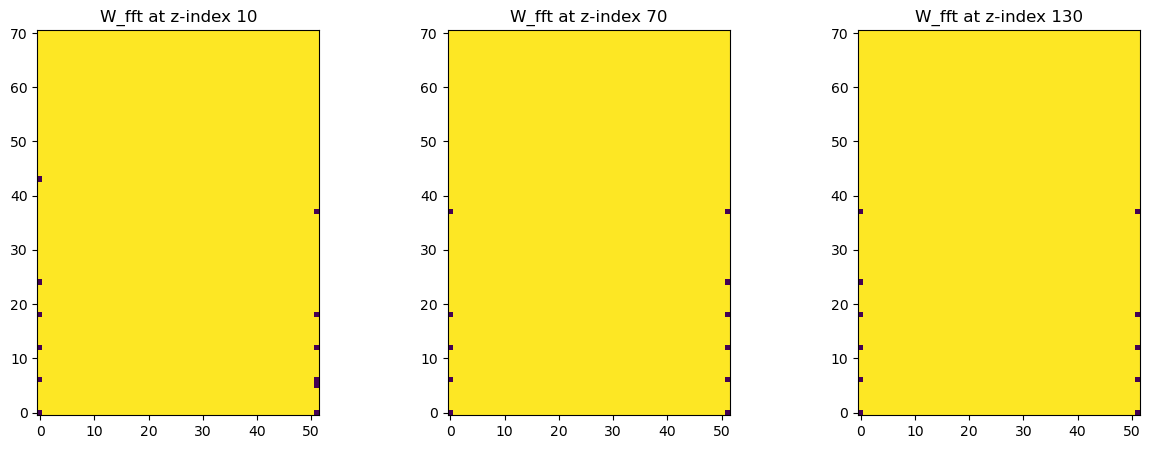

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, zi in zip(axes, [10, nz//2, nz-10]):
    ax.imshow(W_fft[:,:,zi].T, origin='lower')
    ax.set_title(f'W_fft at z-index {zi}')
plt.show()


In [18]:
print(f"x range: [{xp.min():.1f}, {xp.max():.1f}]  vs box [x0, x0+lx] = [{x0:.1f}, {x0+lx:.1f}]")
print(f"y range: [{yp.min():.1f}, {yp.max():.1f}]  vs box [y0, y0+ly] = [{y0:.1f}, {y0+ly:.1f}]")
print(f"z range: [{zp.min():.1f}, {zp.max():.1f}]  vs box [z0, z0+lz] = [{z0:.1f}, {z0+lz:.1f}]")


x range: [-104.7, 104.7]  vs box [x0, x0+lx] = [-105.7, 105.7]
y range: [-146.6, 132.2]  vs box [y0, y0+ly] = [-147.1, 132.9]
z range: [-997.1, -577.7]  vs box [z0, z0+lz] = [-997.1, -577.6]


shouldnt look like this should look like smooth power law like gpr cube and my map

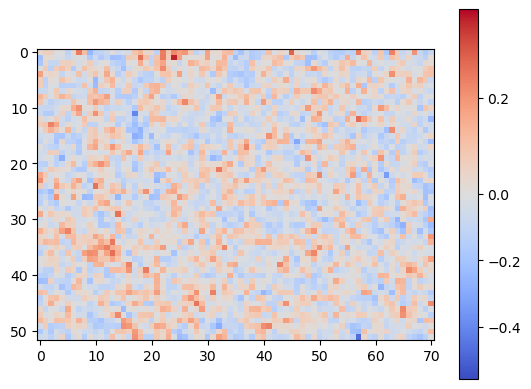

In [19]:
from matplotlib.colors import TwoSlopeNorm
norm=TwoSlopeNorm(vmin=hi_cube.min(), vmax=hi_cube.max(), vcenter=0)
# norm=TwoSlopeNorm(vmin=fg_cube.min(), vmax=fg_cube.max())

# plt.imshow(fg_cube[:,:,0])
plt.imshow(hi_cube[:,:,0],cmap='coolwarm',norm=norm)
plt.colorbar()

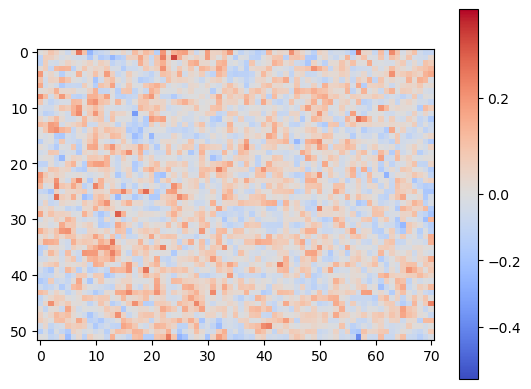

In [20]:
plt.imshow(hi_recovered_cube[:,:,0],cmap='coolwarm',norm=norm)
plt.colorbar()

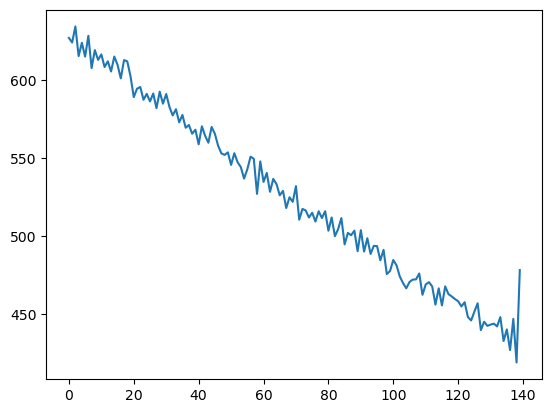

In [21]:
plt.plot(fgds_recovered_cube[0,0,:])

In [22]:
# cartesian_path="/datadec/cppm/shoaib/SMICA_Paper/data/cartesian"
# np.save(f"{cartesian_path}/hi_cube.npy", hi_cube)
# np.save(f"{cartesian_path}/fg_cube.npy", fg_cube)
# np.save(f"{cartesian_path}/noise_cube.npy", noise_cube)
# np.save(f"{cartesian_path}/dirty_cube.npy", dirty_cube)
# np.save(f"{cartesian_path}/W_fft.npy", W_fft)
# np.save(f"{cartesian_path}/dims_fft.npy", dims_fft)
# np.save(f"{cartesian_path}/hi_recovered_cube.npy", hi_recovered_cube)
# np.save(f"{cartesian_path}/fgds_recovered_cube.npy", fgds_recovered_cube)

## P(k) of the regridded fields

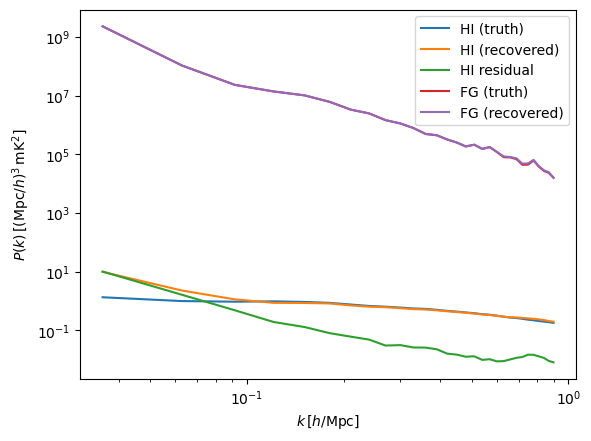

In [23]:
nyq = np.min([nx * np.pi / lx, ny * np.pi / ly, nz * np.pi / lz]) #nyquist
kmax = 1.2 * nyq
kmin = 2 * np.pi / np.max([lx, ly, lz])  # match kbins_par/kbins_perp's fundamental-mode convention (2*pi/L, not 4*pi/L)
deltak = 2 * kmin # / 2
kbins = np.arange(kmin, kmax, deltak)

Pk_hi, k, nmodes = power.Pk(hi_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)
Pk_hi_recovered, _, _ = power.Pk(hi_recovered_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)
Pk_dirty, _, _ = power.Pk(dirty_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)
Pk_fgds, _, _ = power.Pk(fg_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)
Pk_fgds_recovered, _, _ = power.Pk(fgds_recovered_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)

Pk_residucal,_,_=power.Pk(hi_cube-hi_recovered_cube,dims_fft,kbins,w1=W_fft,W1=W_fft)


# np.savez(f"{input_path}/Pk_hi_with_k.npz", k=k, Pk_hi=Pk_hi, nmodes=nmodes)
# np.savez(f"{input_path}/Pk_dirty_with_k.npz", k=k, Pk_dirty=Pk_dirty, nmodes=nmodes)
# np.savez(f"{input_path}/Pk_fgds_with_k.npz", k=k, Pk_fgds=Pk_fgds, nmodes=nmodes)
# print(f"Saved k and P(k) to {input_path}")

plt.plot(k, Pk_hi, label='HI (truth)')
plt.plot(k, Pk_hi_recovered, label='HI (recovered)')
plt.plot(k, Pk_residucal, label='HI residual')
# plt.loglog(k, Pk_dirty, label='Dirty (HI + FG + noise)')
plt.loglog(k, Pk_fgds, label='FG (truth)')
plt.loglog(k, Pk_fgds_recovered, label='FG (recovered)')
plt.xlabel(r'$k\,[h/{\rm Mpc}]$')
plt.ylabel(r'$P(k)\,[({\rm Mpc}/h)^3\,{\rm mK}^2]$')
plt.legend()
plt.show()

## P(k) parallel and perpendicular

In [24]:

from gpr4im import pk_tools as pk

kmin_par = 2*np.pi/lz
dk_par = 2*kmin_par
kmax_par = nz*np.pi/lz

kbins_par = np.arange(kmin_par, kmax_par, dk_par)
kpar_c = np.linspace(kmin_par+0.5*dk_par, kmax_par-0.5*dk_par, len(kbins_par)-1)

kmin_perp = 2*np.pi/np.sqrt(lx**2+ly**2)
dk_perp = 2*kmin_perp
kmax_perp = min(nx*np.pi/lx, ny*np.pi/ly)
kbins_perp = np.arange(kmin_perp, kmax_perp, dk_perp)
kperp_c = np.linspace(kmin_perp+0.5*dk_perp, kmax_perp-0.5*dk_perp, len(kbins_perp)-1)

hi_pk_para, nmodes_para = pk.ParaPk(hi_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
hi_pk_perp, nmodes_perp = pk.PerpPk(hi_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
hi_pk2d, nmodes2d = pk.PerpParaPk(hi_cube, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft)

fgds_pk_para, nmodes_para = pk.ParaPk(fg_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
fgds_pk_perp, nmodes_perp = pk.PerpPk(fg_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
fgds_pk2d, nmodes2d = pk.PerpParaPk(fg_cube, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft)

hi_recovered_pk_para, nmodes_para = pk.ParaPk(hi_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
hi_recovered_pk_perp, nmodes_perp = pk.PerpPk(hi_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
hi_recovered_pk2d, nmodes2d = pk.PerpParaPk(hi_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft) 

fgds_recovered_pk_para, nmodes_para = pk.ParaPk(fgds_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
fgds_recovered_pk_perp, nmodes_perp = pk.PerpPk(fgds_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
fgds_recovered_pk2d, nmodes2d = pk.PerpParaPk(fgds_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft)

residual_pk_para, nmodes_para = pk.ParaPk(hi_cube-hi_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
residual_pk_perp, nmodes_perp = pk.PerpPk(hi_cube-hi_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
residual_pk2d, nmodes2d = pk.PerpParaPk(hi_cube-hi_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft)


residual_fg_pk_para, nmodes_para = pk.ParaPk(fg_cube-fgds_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
residual_fg_pk_perp, nmodes_perp = pk.PerpPk(fg_cube-fgds_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
residual_fg_pk2d, nmodes2d = pk.PerpParaPk(fg_cube-fgds_recovered_cube, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft)



Calculating P(k_perp,k_para)...

Calculating P(k_perp,k_para)...

Calculating P(k_perp,k_para)...

Calculating P(k_perp,k_para)...

Calculating P(k_perp,k_para)...

Calculating P(k_perp,k_para)...


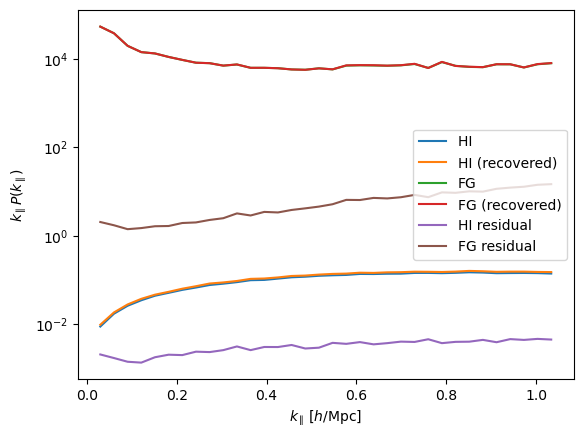

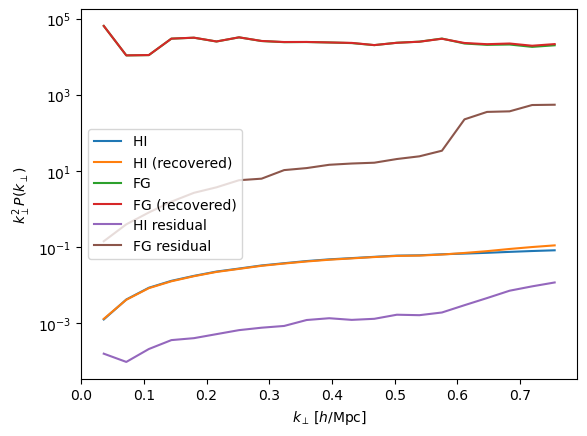

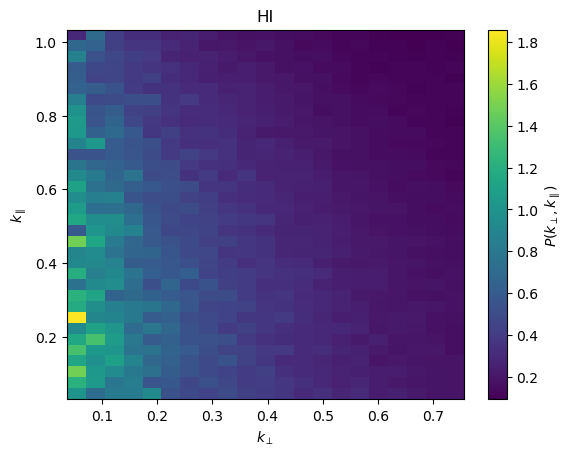

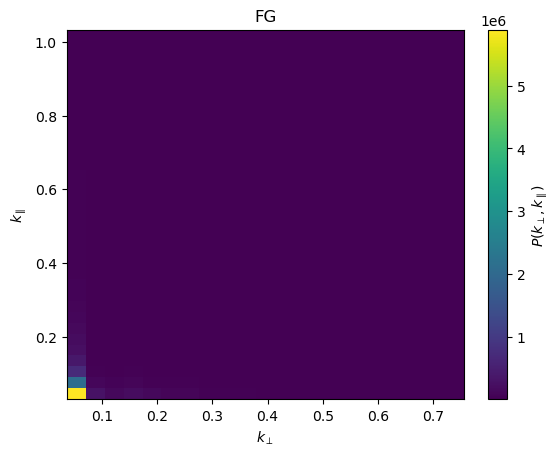

In [25]:
plt.plot(kpar_c, kpar_c*hi_pk_para, label='HI ')
plt.plot(kpar_c, kpar_c*hi_recovered_pk_para, label='HI (recovered)')
plt.plot(kpar_c, kpar_c*fgds_pk_para, label='FG')
plt.plot(kpar_c, kpar_c*fgds_recovered_pk_para, label='FG (recovered)')
plt.plot(kpar_c, kpar_c*residual_pk_para, label='HI residual')
plt.plot(kpar_c, kpar_c*residual_fg_pk_para, label='FG residual')
plt.xlabel(r'$k_\parallel\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\parallel P(k_\parallel)$')
plt.yscale('log')
# plt.xscale('log')
plt.legend()
plt.show()
#
plt.plot(kperp_c, kperp_c**2*hi_pk_perp, label='HI ')
plt.plot(kperp_c, kperp_c**2*hi_recovered_pk_perp, label='HI (recovered)')
plt.plot(kperp_c, kperp_c**2*fgds_pk_perp, label='FG')
plt.plot(kperp_c, kperp_c**2*fgds_recovered_pk_perp, label='FG (recovered)')
plt.plot(kperp_c, kperp_c**2*residual_pk_perp, label='HI residual')
plt.plot(kperp_c, kperp_c**2*residual_fg_pk_perp, label='FG residual')
plt.xlabel(r'$k_\perp\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\perp^2 P(k_\perp)$')
plt.yscale('log')
plt.legend()
plt.show()

plt.imshow(hi_pk2d, origin='lower', extent=[kperp_c[0],kperp_c[-1],kpar_c[0],kpar_c[-1]], aspect='auto')
plt.title('HI')
plt.xlabel(r'$k_\perp$'); plt.ylabel(r'$k_\parallel$'); plt.colorbar(label=r'$P(k_\perp,k_\parallel)$')
plt.show()

plt.imshow(fgds_pk2d, origin='lower', extent=[kperp_c[0],kperp_c[-1],kpar_c[0],kpar_c[-1]], aspect='auto')
plt.title('FG')
plt.xlabel(r'$k_\perp$'); plt.ylabel(r'$k_\parallel$'); plt.colorbar(label=r'$P(k_\perp,k_\parallel)$')
plt.show()



# GPR data visualisation

In [26]:
import pandas as pd
from gpr4im import pk_tools as pk
data = pd.read_pickle('/datadec/cppm/shoaib/gpr4im/Data/example_data.pkl')
fgds_gpr = np.array(data.beam.FGnopol)      # (128,128,142)
hi_gpr   = np.array(data.beam.HI_noise)     # (128,128,142)

lx_g, ly_g, lz_g = 500.0, 500.0, 460.77
nx_g, ny_g, nz_g = fgds_gpr.shape
w_g = W_g = np.ones((nx_g, ny_g, nz_g))

kmax_par_g  = nz_g*np.pi/lz_g
kmax_perp_g = min(nx_g*np.pi/lx_g, ny_g*np.pi/ly_g)

kmin_par_g = 2*np.pi/lz_g
dk_par_g = 2*kmin_par_g
kbins_par_g = np.arange(kmin_par_g, kmax_par_g, dk_par_g)
kpar_g = np.linspace(kmin_par_g+0.5*dk_par_g, kmax_par_g-0.5*dk_par_g, len(kbins_par_g)-1)

kmin_perp_g = 2*np.pi/np.sqrt(lx_g**2+ly_g**2)
dk_perp_g = 2*kmin_perp_g
kbins_perp_g = np.arange(kmin_perp_g, kmax_perp_g, dk_perp_g)
kperp_g = np.linspace(kmin_perp_g+0.5*dk_perp_g, kmax_perp_g-0.5*dk_perp_g, len(kbins_perp_g)-1)

fgpk_para_g, _ = pk.ParaPk(fgds_gpr, nx_g, ny_g, nz_g, lx_g, ly_g, lz_g, kbins_par_g, w_g, W_g)
fgpk_perp_g, _ = pk.PerpPk(fgds_gpr, nx_g, ny_g, nz_g, lx_g, ly_g, lz_g, kbins_perp_g, w_g, W_g)
hipk_para_g, _ = pk.ParaPk(hi_gpr, nx_g, ny_g, nz_g, lx_g, ly_g, lz_g, kbins_par_g, w_g, W_g)
hipk_perp_g, _ = pk.PerpPk(hi_gpr, nx_g, ny_g, nz_g, lx_g, ly_g, lz_g, kbins_perp_g, w_g, W_g)


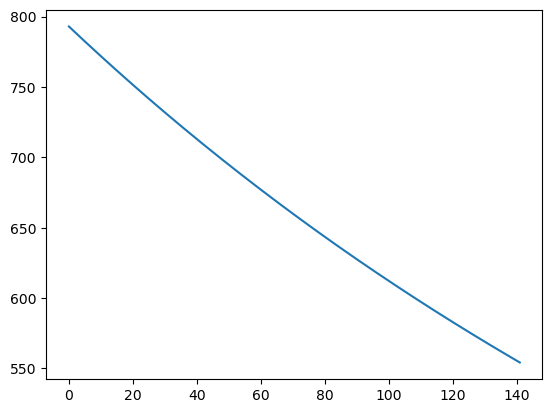

In [27]:
plt.plot(fgds_gpr[0,0,:])

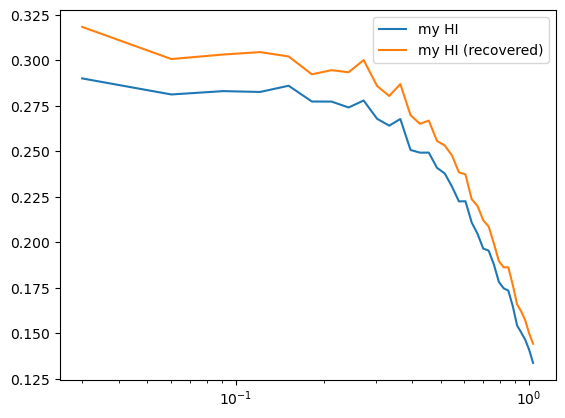

In [28]:
plt.plot(kpar_c, hi_pk_para, label='my HI')
plt.plot(kpar_c, hi_recovered_pk_para, label='my HI (recovered)')
# plt.plot(kpar_g, hipk_para_g, label='GPR example: HI+noise', ls='--')
plt.xscale('log')
plt.legend()

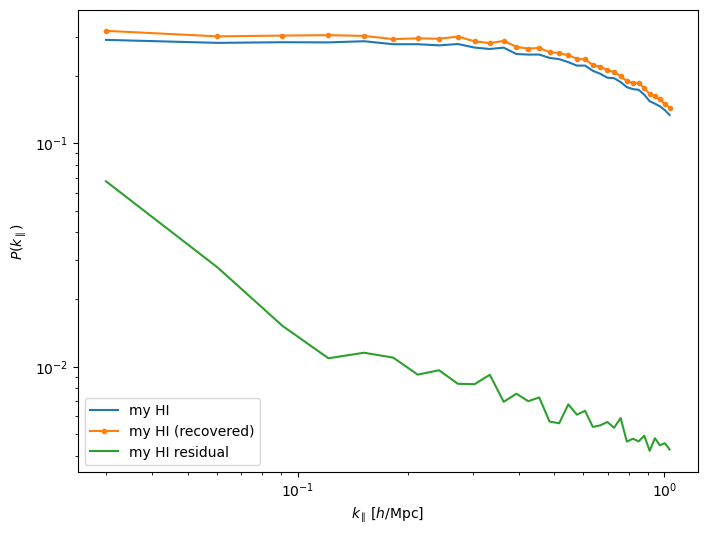

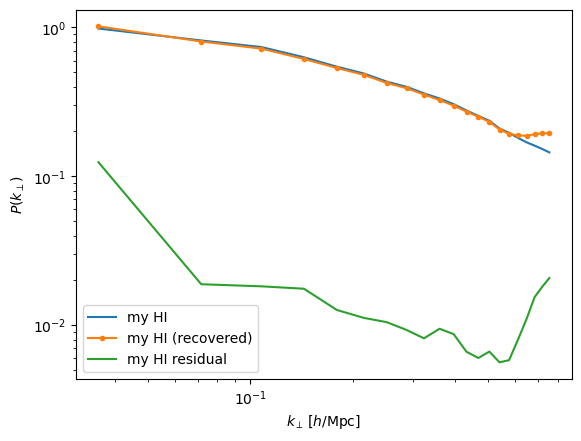

In [29]:
plt.figure(figsize=(8,6))
plt.plot(kpar_c, hi_pk_para, label='my HI')
plt.plot(kpar_c, hi_recovered_pk_para, '.-',label='my HI (recovered)')
plt.plot(kpar_c, residual_pk_para, label='my HI residual')
# plt.plot(kpar_g, kpar_g*hipk_para_g, label='GPR example: HI+noise', ls='--')
# plt.plot(kpar_c, fgds_pk_para, label='my FG')
# plt.plot(kpar_c, fgds_recovered_pk_para, '.',label='my FG (recovered)')
# plt.plot(kpar_c, residual_fg_pk_para, label='FG residual')
# plt.plot(kpar_g, fgpk_para_g, label='GPR example: FG', ls='--')
plt.xlabel(r'$k_\parallel\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$  P(k_\parallel)$')
plt.yscale('log')
plt.xscale('log')
plt.legend(); plt.show()
plt.show()

# plt.plot(kperp_g, hipk_perp_g, label='GPR example: HI+noise', ls='--')
plt.plot(kperp_c, hi_pk_perp, label='my HI')
plt.plot(kperp_c, hi_recovered_pk_perp, '.-',label='my HI (recovered)')
plt.plot(kperp_c, residual_pk_perp, label='my HI residual')
# plt.plot(kperp_c, fgds_pk_perp, label='my FG')
# plt.plot(kperp_c, fgds_recovered_pk_perp, '.',label='my FG (recovered)')
# plt.plot(kperp_c, residual_fg_pk_perp, label='FG residual')
# plt.plot(kperp_g, fgpk_perp_g, label='GPR example: FG', ls='--')
plt.xlabel(r'$k_\perp\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$ P(k_\perp)$')
plt.yscale('log')
plt.xscale('log')
plt.legend(); plt.show()

## Regrid the SMICA-recovered maps and compare $P(k)$ to truth

Loads the Wiener-filter-reconstructed HI/FG maps produced in `SMICA.ipynb` (`hi_recovered.npy`/
`fg_recovered.npy`, same celestial frame as the truth cubes above) and regrids them with the identical
particle geometry (`to_cartesian`), so the recovered and truth $P(k)$ are directly comparable.

In [30]:
hi_recovered_cube_10bins = np.load(f"/datadec/cppm/shoaib/SMICA_Paper/data/cartesian/hi_recovered_cube.npy")  # mK, celestial -- bins=10
fg_recovered_cube_10bins = np.load(f"/datadec/cppm/shoaib/SMICA_Paper/data/cartesian/fgds_recovered_cube.npy")  # mK, celestial


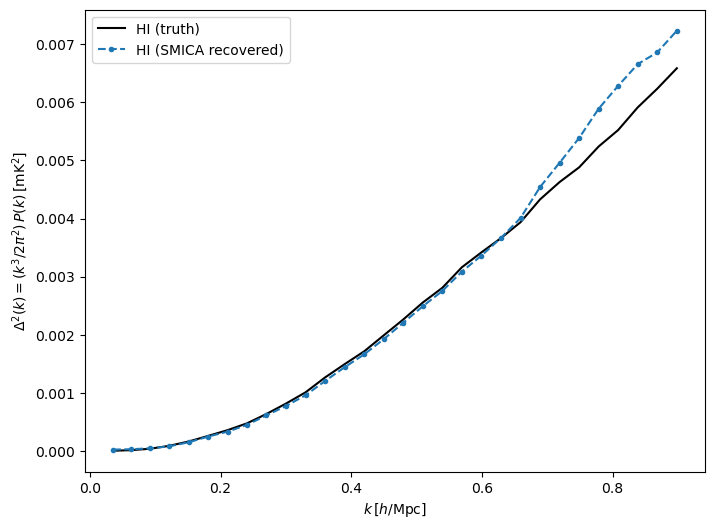

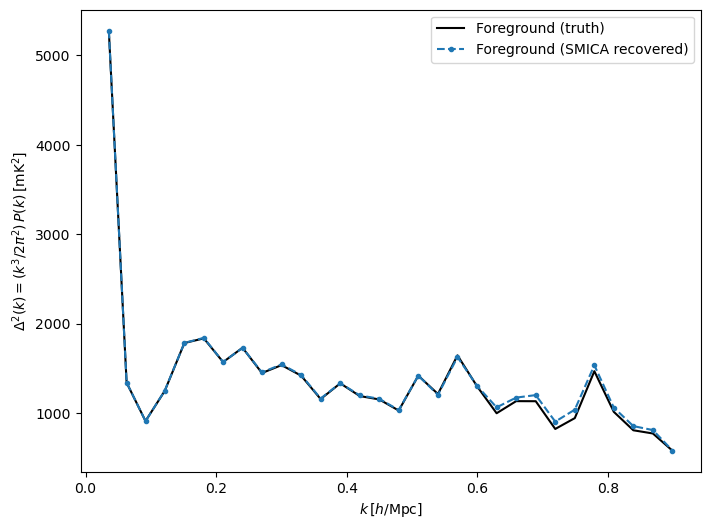

In [31]:
Pk_hi_recovered, _, _ = power.Pk(hi_recovered_cube_10bins, dims_fft, kbins, w1=W_fft, W1=W_fft)
Pk_fg_recovered, _, _ = power.Pk(fg_recovered_cube_10bins, dims_fft, kbins, w1=W_fft, W1=W_fft)

Delta2=lambda Pk: (k**3/(2*np.pi**2))*Pk

plt.figure(figsize=(8, 6))
plt.plot(k, Delta2(Pk_hi), 'k-', label='HI (truth)')
plt.plot(k, Delta2(Pk_hi_recovered), '.--', label='HI (SMICA recovered)')
plt.ylabel(r'$\Delta^2(k) = (k^3/2\pi^2)\,P(k)\,[{\rm mK}^2]$')
plt.xlabel(r'$k\,[h/{\rm Mpc}]$')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(k, Delta2(Pk_fgds), 'k-', label='Foreground (truth)')
plt.plot(k, Delta2(Pk_fg_recovered), '.--', label='Foreground (SMICA recovered)')
plt.ylabel(r'$\Delta^2(k) = (k^3/2\pi^2)\,P(k)\,[{\rm mK}^2]$')
plt.xlabel(r'$k\,[h/{\rm Mpc}]$')
plt.legend()
plt.show()

In [32]:
hi_recovered_pk_para_10bins, nmodes_para = pk.ParaPk(hi_recovered_cube_10bins, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
hi_recovered_pk_perp_10bins, nmodes_perp = pk.PerpPk(hi_recovered_cube_10bins, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
hi_recovered_pk2d_10bins, nmodes2d = pk.PerpParaPk(hi_recovered_cube_10bins, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft) 

fg_recovered_pk_para_10bins, nmodes_para = pk.ParaPk(fg_recovered_cube_10bins, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
fg_recovered_pk_perp_10bins, nmodes_perp = pk.PerpPk(fg_recovered_cube_10bins, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
fg_recovered_pk2d_10bins, nmodes2d = pk.PerpParaPk(fg_recovered_cube_10bins, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft)

residual_pk_para_10bins, nmodes_para = pk.ParaPk(hi_cube-hi_recovered_cube_10bins, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
residual_pk_perp_10bins, nmodes_perp = pk.PerpPk(hi_cube-hi_recovered_cube_10bins, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
residual_pk2d_10bins, nmodes2d = pk.PerpParaPk(hi_cube-hi_recovered_cube_10bins, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft)


residual_fg_pk_para_10bins, nmodes_para = pk.ParaPk(fg_cube-fg_recovered_cube_10bins, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
residual_fg_pk_perp_10bins, nmodes_perp = pk.PerpPk(fg_cube-fg_recovered_cube_10bins, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)



Calculating P(k_perp,k_para)...

Calculating P(k_perp,k_para)...

Calculating P(k_perp,k_para)...


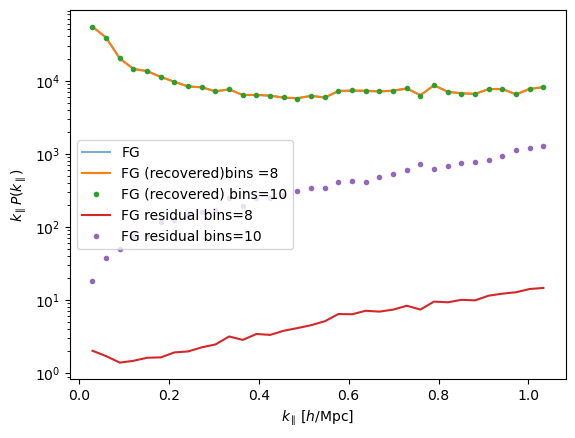

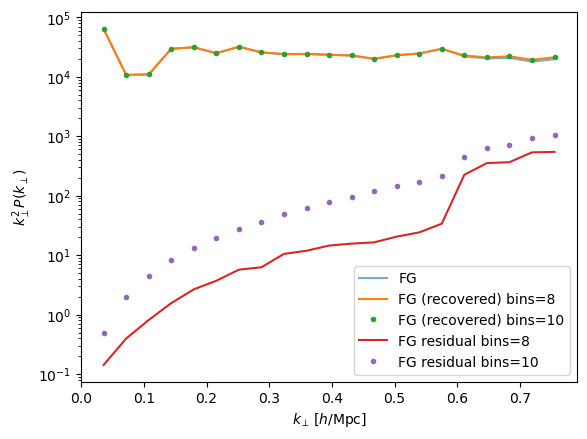

In [33]:
plt.plot(kpar_c, kpar_c*fgds_pk_para, label='FG', alpha=0.6)
plt.plot(kpar_c, kpar_c*fgds_recovered_pk_para, label='FG (recovered)bins =8')
plt.plot(kpar_c, kpar_c*fg_recovered_pk_para_10bins, '.',label='FG (recovered) bins=10')
plt.plot(kpar_c, kpar_c*residual_fg_pk_para,label='FG residual bins=8')
plt.plot(kpar_c, kpar_c*residual_fg_pk_para_10bins, '.', label='FG residual bins=10')
plt.xlabel(r'$k_\parallel\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\parallel P(k_\parallel)$')
plt.yscale('log')
# plt.xscale('log')
plt.legend()
plt.show()


plt.plot(kperp_c, kperp_c**2*fgds_pk_perp, label='FG', alpha=0.6)
plt.plot(kperp_c, kperp_c**2*fgds_recovered_pk_perp, label='FG (recovered) bins=8')
plt.plot(kperp_c, kperp_c**2*fg_recovered_pk_perp_10bins, '.', label='FG (recovered) bins=10')

plt.plot(kperp_c, kperp_c**2*residual_fg_pk_perp, label='FG residual bins=8')
plt.plot(kperp_c, kperp_c**2*residual_fg_pk_perp_10bins, '.', label='FG residual bins=10')
plt.xlabel(r'$k_\perp\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\perp^2 P(k_\perp)$')
plt.yscale('log')
plt.legend()
plt.show()





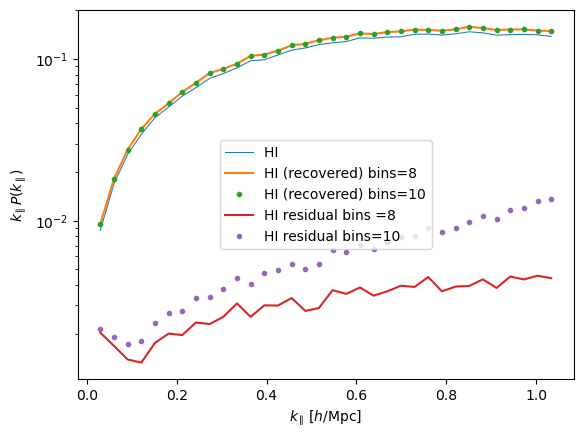

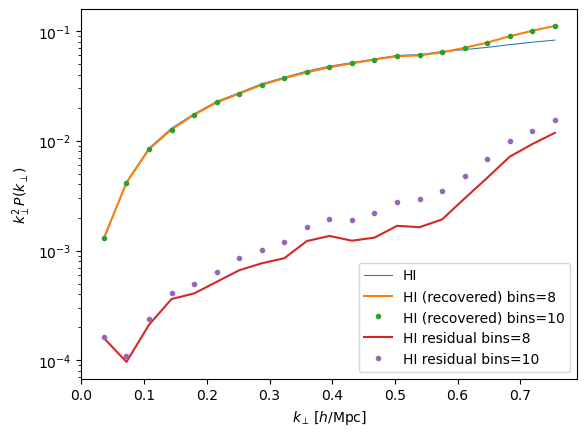

In [34]:
plt.plot(kpar_c, kpar_c*hi_pk_para, label='HI ', lw=0.75)
plt.plot(kpar_c, kpar_c*hi_recovered_pk_para, label='HI (recovered) bins=8')
plt.plot(kpar_c, kpar_c*hi_recovered_pk_para_10bins, '.',label='HI (recovered) bins=10')
plt.plot(kpar_c, kpar_c*residual_pk_para, label='HI residual bins =8')
plt.plot(kpar_c, kpar_c*residual_pk_para_10bins, '.',label='HI residual bins=10')
plt.xlabel(r'$k_\parallel\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\parallel P(k_\parallel)$')
plt.yscale('log')
# plt.xscale('log')
plt.legend()
plt.show()

plt.plot(kperp_c, kperp_c**2*hi_pk_perp, label='HI', lw=0.75)
plt.plot(kperp_c, kperp_c**2*hi_recovered_pk_perp, label='HI (recovered) bins=8')
plt.plot(kperp_c, kperp_c**2*hi_recovered_pk_perp_10bins, '.',label='HI (recovered) bins=10')
plt.plot(kperp_c, kperp_c**2*residual_pk_perp, label='HI residual bins=8')
plt.plot(kperp_c, kperp_c**2*residual_pk_perp_10bins, '.',label='HI residual bins=10')
plt.xlabel(r'$k_\perp\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\perp^2 P(k_\perp)$')
plt.yscale('log')
plt.legend()
plt.show()





## Comparison with PCA

In [42]:
hi_noise_PCA=np.load(f"/datadec/cppm/shoaib/SMICA_Paper/data/UHF/hi_noise_PCA.npy")  
fg_PCA=np.load(f"/datadec/cppm/shoaib/SMICA_Paper/data/UHF/fg_PCA.npy")  

hi_noise_pca_cube, _ = to_cartesian(hi_noise_PCA)
fg_pca_cube, _ = to_cartesian(fg_PCA)
noise_cube,_= to_cartesian(noise)

print("Recovered cube shape (nx,ny,nz):", hi_noise_pca_cube.shape)


Cartesian regridding summary:
 - Minimum number of particles in grid cell: 1.8250264354899046
 - Maximum number of particles in grid cell: 109.3062367374932
 - Mean number of particles in grid cell: 75.393
 - Number of missing particles: 0

Cartesian regridding summary:
 - Minimum number of particles in grid cell: 1.8250264354899046
 - Maximum number of particles in grid cell: 109.3062367374932
 - Mean number of particles in grid cell: 75.393
 - Number of missing particles: 0

Cartesian regridding summary:
 - Minimum number of particles in grid cell: 1.8250264354899046
 - Maximum number of particles in grid cell: 109.3062367374932
 - Mean number of particles in grid cell: 75.393
 - Number of missing particles: 0
Recovered cube shape (nx,ny,nz): (52, 71, 140)


In [45]:
signal=hi_cube+noise_cube
Pk_signal,_,_=power.Pk(signal, dims_fft, kbins, w1=W_fft, W1=W_fft)
signal_pk_para, _= pk.ParaPk(signal, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
signal_pk_perp, _= pk.PerpPk(signal, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)

In [ ]:
Pk_hi_noise_pca, _, _ = power.Pk(hi_noise_pca_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)
Pk_fg_pca, _, _ = power.Pk(fg_pca_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)

hi_noise_pk_para_pca, nmodes_para = pk.ParaPk(hi_noise_pca_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
hi_noise_pk_perp_pca, nmodes_perp = pk.PerpPk(hi_noise_pca_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
hi_noise_pk2d_pca, nmodes2d = pk.PerpParaPk(hi_noise_pca_cube, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft) 

fg_pk_para_pca, nmodes_para = pk.ParaPk(fg_pca_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
fg_pk_perp_pca, nmodes_perp = pk.PerpPk(fg_pca_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
fg_pk2d_pca, nmodes2d = pk.PerpParaPk(fg_pca_cube, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft)

residual_pk_para_pca, nmodes_para = pk.ParaPk(signal-hi_noise_pca_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
residual_pk_perp_pca, nmodes_perp = pk.PerpPk(signal-hi_noise_pca_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
residual_pk2d_pca, nmodes2d = pk.PerpParaPk(signal-hi_noise_pca_cube, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft)


residual_fg_pk_para_pca, nmodes_para = pk.ParaPk(fg_cube-fg_pca_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
residual_fg_pk_perp_pca, nmodes_perp = pk.PerpPk(fg_cube-fg_pca_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)



Calculating P(k_perp,k_para)...

Calculating P(k_perp,k_para)...

Calculating P(k_perp,k_para)...


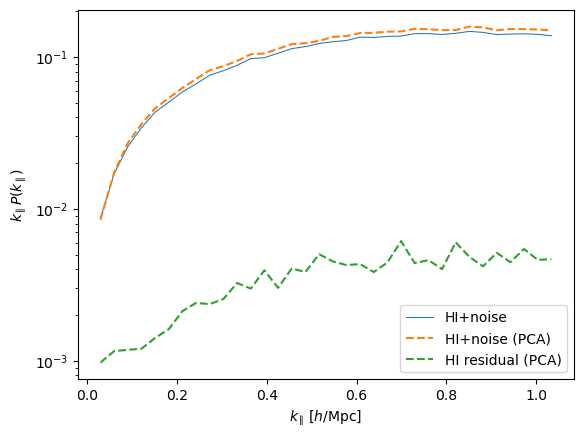

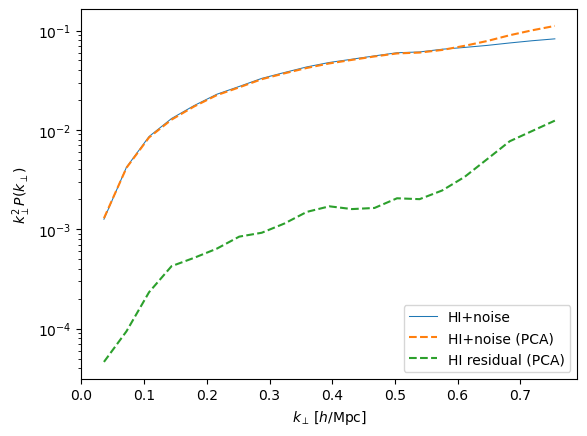

In [47]:
# plt.plot(kpar_c, kpar_c*hi_pk_para, label='HI ', lw=0.75)
plt.plot(kpar_c, kpar_c*signal_pk_para, label='HI+noise', lw=0.75)
# plt.plot(kpar_c, kpar_c*hi_recovered_pk_para, label='HI (recovered) bins=8')
# plt.plot(kpar_c, kpar_c*hi_recovered_pk_para_10bins, '.',label='HI (recovered) bins=10')
plt.plot(kpar_c, kpar_c*hi_noise_pk_para_pca, '--',label='HI+noise (PCA) ')

# plt.plot(kpar_c, kpar_c*residual_pk_para, label='HI residual bins =8')
# plt.plot(kpar_c, kpar_c*residual_pk_para_10bins, '.',label='HI residual bins=10')
plt.plot(kpar_c, kpar_c*residual_pk_para_pca, '--',label='HI residual (PCA)')
plt.xlabel(r'$k_\parallel\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\parallel P(k_\parallel)$')
plt.yscale('log')
# plt.xscale('log')
plt.legend()
plt.show()

# plt.plot(kperp_c, kperp_c**2*hi_pk_perp, label='HI', lw=0.75)
plt.plot(kperp_c, kperp_c**2*signal_pk_perp, label='HI+noise', lw=0.75)
# plt.plot(kperp_c, kperp_c**2*hi_recovered_pk_perp, label='HI (recovered) bins=8')
# plt.plot(kperp_c, kperp_c**2*hi_recovered_pk_perp_10bins, '.',label='HI (recovered) bins=10')
plt.plot(kperp_c, kperp_c**2*hi_noise_pk_perp_pca, '--',label='HI+noise (PCA) ')

# plt.plot(kperp_c, kperp_c**2*residual_pk_perp, label='HI residual bins=8')
# plt.plot(kperp_c, kperp_c**2*residual_pk_perp_10bins, '.',label='HI residual bins=10')
plt.plot(kperp_c, kperp_c**2*residual_pk_perp_pca, '--',label='HI residual (PCA)')
plt.xlabel(r'$k_\perp\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\perp^2 P(k_\perp)$')
plt.yscale('log')
plt.legend()
plt.show()

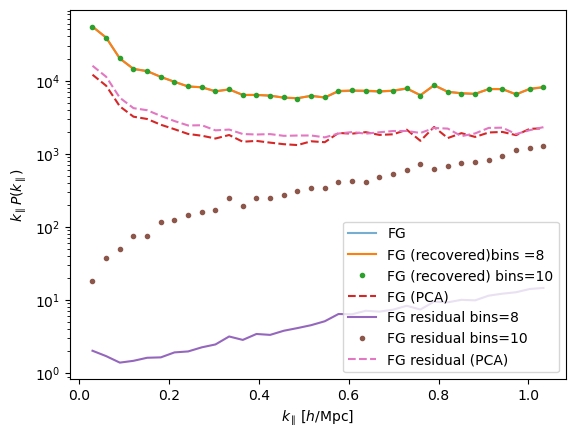

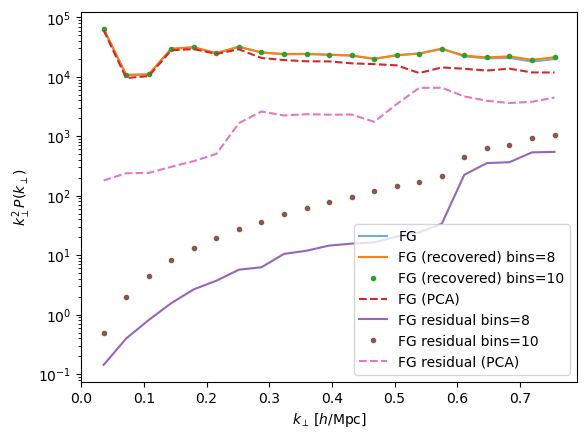

In [38]:
plt.plot(kpar_c, kpar_c*fgds_pk_para, label='FG', alpha=0.6)
plt.plot(kpar_c, kpar_c*fgds_recovered_pk_para, label='FG (recovered)bins =8')
plt.plot(kpar_c, kpar_c*fg_recovered_pk_para_10bins, '.',label='FG (recovered) bins=10')
plt.plot(kpar_c, kpar_c*fg_noise_pk_para_pca, '--',label='FG (PCA) ')

plt.plot(kpar_c, kpar_c*residual_fg_pk_para,label='FG residual bins=8')
plt.plot(kpar_c, kpar_c*residual_fg_pk_para_10bins, '.', label='FG residual bins=10')
plt.plot(kpar_c, kpar_c*residual_fg_pk_para_pca, '--',label='FG residual (PCA)')
plt.xlabel(r'$k_\parallel\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\parallel P(k_\parallel)$')
plt.yscale('log')
# plt.xscale('log')
plt.legend()
plt.show()


plt.plot(kperp_c, kperp_c**2*fgds_pk_perp, label='FG', alpha=0.6)
plt.plot(kperp_c, kperp_c**2*fgds_recovered_pk_perp, label='FG (recovered) bins=8')
plt.plot(kperp_c, kperp_c**2*fg_recovered_pk_perp_10bins, '.', label='FG (recovered) bins=10')
plt.plot(kperp_c, kperp_c**2*fg_noise_pk_perp_pca, '--',label='FG (PCA) ')

plt.plot(kperp_c, kperp_c**2*residual_fg_pk_perp, label='FG residual bins=8')
plt.plot(kperp_c, kperp_c**2*residual_fg_pk_perp_10bins, '.', label='FG residual bins=10')
plt.plot(kperp_c, kperp_c**2*residual_fg_pk_perp_pca, '--',label='FG residual (PCA)')
plt.xlabel(r'$k_\perp\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\perp^2 P(k_\perp)$')
plt.yscale('log')
plt.legend()
plt.show()

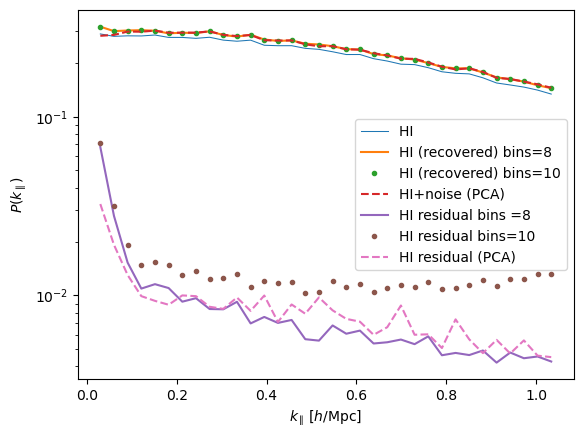

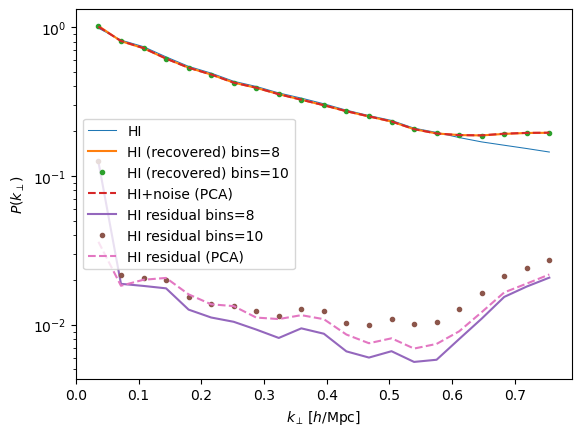

In [39]:
plt.plot(kpar_c, hi_pk_para, label='HI ', lw=0.75)
plt.plot(kpar_c, hi_recovered_pk_para, label='HI (recovered) bins=8')
plt.plot(kpar_c, hi_recovered_pk_para_10bins, '.',label='HI (recovered) bins=10')
plt.plot(kpar_c, hi_noise_pk_para_pca, '--',label='HI+noise (PCA) ')

plt.plot(kpar_c, residual_pk_para, label='HI residual bins =8')
plt.plot(kpar_c, residual_pk_para_10bins, '.',label='HI residual bins=10')
plt.plot(kpar_c, residual_pk_para_pca, '--',label='HI residual (PCA)')
plt.xlabel(r'$k_\parallel\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$ P(k_\parallel)$')
plt.yscale('log')
# plt.xscale('log')
plt.legend()
plt.show()

plt.plot(kperp_c, hi_pk_perp, label='HI', lw=0.75)
plt.plot(kperp_c, hi_recovered_pk_perp, label='HI (recovered) bins=8')
plt.plot(kperp_c, hi_recovered_pk_perp_10bins, '.',label='HI (recovered) bins=10')
plt.plot(kperp_c, hi_noise_pk_perp_pca, '--',label='HI+noise (PCA) ')

plt.plot(kperp_c, residual_pk_perp, label='HI residual bins=8')
plt.plot(kperp_c, residual_pk_perp_10bins, '.',label='HI residual bins=10')
plt.plot(kperp_c, residual_pk_perp_pca, '--',label='HI residual (PCA)')
plt.xlabel(r'$k_\perp\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$ P(k_\perp)$')
plt.yscale('log')
plt.legend()
plt.show()

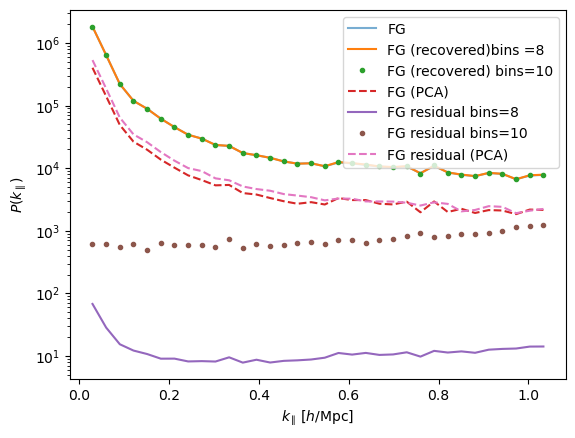

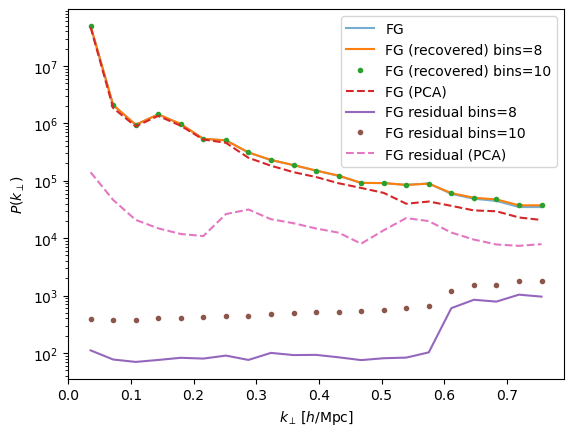

In [40]:
plt.plot(kpar_c, fgds_pk_para, label='FG', alpha=0.6)
plt.plot(kpar_c, fgds_recovered_pk_para, label='FG (recovered)bins =8')
plt.plot(kpar_c, fg_recovered_pk_para_10bins, '.',label='FG (recovered) bins=10')
plt.plot(kpar_c, fg_noise_pk_para_pca, '--',label='FG (PCA) ')

plt.plot(kpar_c, residual_fg_pk_para,label='FG residual bins=8')
plt.plot(kpar_c, residual_fg_pk_para_10bins, '.', label='FG residual bins=10')
plt.plot(kpar_c, residual_fg_pk_para_pca, '--',label='FG residual (PCA)')
plt.xlabel(r'$k_\parallel\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$P(k_\parallel)$')
plt.yscale('log')
# plt.xscale('log')
plt.legend()
plt.show()


plt.plot(kperp_c, fgds_pk_perp, label='FG', alpha=0.6)
plt.plot(kperp_c, fgds_recovered_pk_perp, label='FG (recovered) bins=8')
plt.plot(kperp_c, fg_recovered_pk_perp_10bins, '.', label='FG (recovered) bins=10')
plt.plot(kperp_c, fg_noise_pk_perp_pca, '--',label='FG (PCA) ')

plt.plot(kperp_c, residual_fg_pk_perp, label='FG residual bins=8')
plt.plot(kperp_c, residual_fg_pk_perp_10bins, '.', label='FG residual bins=10')
plt.plot(kperp_c, residual_fg_pk_perp_pca, '--',label='FG residual (PCA)')
plt.xlabel(r'$k_\perp\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$ P(k_\perp)$')
plt.yscale('log')
plt.legend()
plt.show()

## Save cubes for downstream GPR cleaning / covariance comparison

In [ ]:
# out_path = f"{input_path}/cartesian"
# os.makedirs(out_path, exist_ok=True)

# np.save(f"{out_path}/hi_cube.npy", hi_cube)
# np.save(f"{out_path}/fg_cube.npy", fg_cube)
# np.save(f"{out_path}/noise_cube.npy", noise_cube)
# np.save(f"{out_path}/dirty_cube.npy", dirty_cube)
# np.save(f"{out_path}/W_fft.npy", W_fft)
# np.save(f"{out_path}/nu.npy", nu)
# np.save(f"{out_path}/dims_fft.npy", np.array(dims_fft, dtype=object))

# print(f"Saved Cartesian cubes to {out_path}")